# Negative Triangularity Analysis

In [2]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real
from tqdm.notebook import tqdm

import pickle

In [4]:
# %% Load my own libraries
%load_ext autoreload
%autoreload 2
from c1lgkt.jax.fields.field_providers import EikonalFieldProvider, ZonalFieldProvider
import c1lgkt.jax.particles.particle_motion as particle_motion
import c1lgkt.jax.particles.particle_tools as particle_tools
from c1lgkt.jax.analysis.wba import wba_weights
from c1lgkt.jax.analysis.configuration import load_yaml_config, realize_initial_conditions

In [ ]:
# %% Load the configuration
args, ic_gen = load_yaml_config('./scratch/data/nt_analysis.yaml')
y0, mask, ic = realize_initial_conditions(ic_gen, args)

eq = args.eq

t0 = 0.0

Loaded theta and clebsch mapping from file


Text(0.5, 1.0, 'p193802.04490')

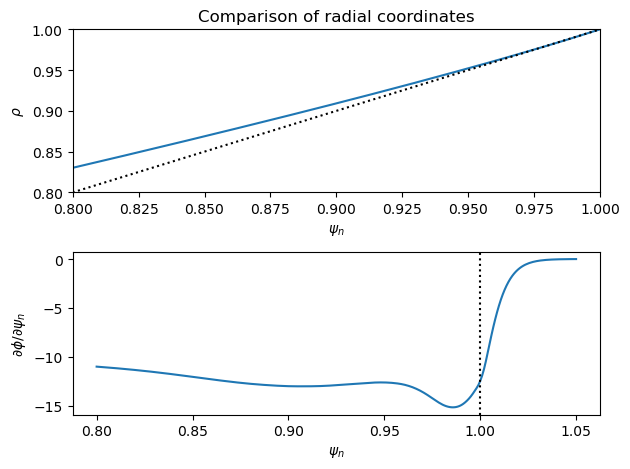

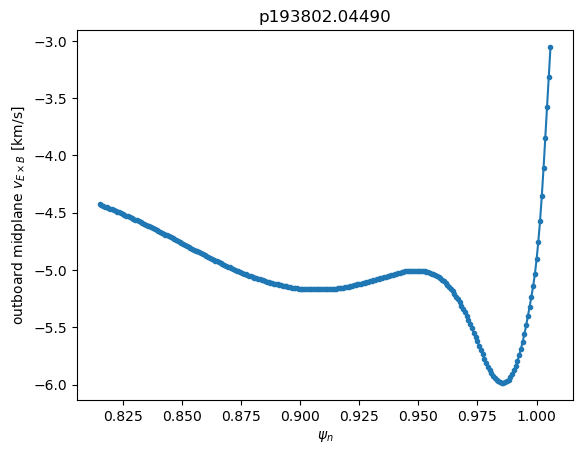

In [8]:
# %% Set up fields

# Load Er from pfile
zonal_field: ZonalFieldProvider = args.fields[0] # pyright: ignore
eikonal_field: EikonalFieldProvider = args.fields[1] # pyright: ignore
clebsch = eikonal_field.clebsch
theta_map = eikonal_field.theta_map

# Compute the toroidal flux coordinate for comparison with stewart et al.
psinorm = np.linspace(0.0, 1.0, 256)
mids = (psinorm[1:] + psinorm[:-1]) * 0.5
# Use midpoint rule to compute the toroidal flux
q_clebsch = (clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, jnp.pi)) - clebsch.interp_alpha(mids*eq.psix, jnp.full_like(mids, -jnp.pi))) / (2 * jnp.pi)
torflux = np.concatenate([np.array([0.0]), np.cumsum(q_clebsch)])
rhonorm = np.sqrt(torflux / torflux[-1])

plt.figure()

plt.subplot(211)
plt.plot(psinorm, rhonorm)
plt.plot([0.8, 1.0], [0.8, 1.0], ls=':', c='k')
plt.xlim(0.8, 1.0)
plt.ylim(0.8, 1.0)
plt.title('Comparison of radial coordinates')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\rho$')


plt.subplot(212)
psi_plot = jnp.linspace(eq.psix*0.8, eq.psix*1.05, 256)
phi_plot = -zonal_field.interp(psi_plot, dx=1)
plt.plot(psi_plot/eq.psix, phi_plot)
plt.axvline(1.0, ls=':', c='k')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R'$\partial\phi / \partial \psi_n$')

plt.tight_layout()

plt.figure()

r_plot = jnp.linspace(2.25, 2.303, 256)
psi_plot_2 = eq.interp_psi(r_plot, jnp.full_like(r_plot, eq.zaxis))
bv_plot = eq.compute_bv(r_plot, jnp.full_like(r_plot, eq.zaxis))
modb_plot = jnp.linalg.norm(bv_plot, axis=0)
dpsi_dr = eq.interp_psi(r_plot, jnp.full_like(r_plot, eq.zaxis), dx=1)
plt.plot(psi_plot_2/eq.psix, -zonal_field.interp(psi_plot_2, dx=1)*dpsi_dr / modb_plot, marker='.')
plt.xlabel(R'$\psi_n$')
plt.ylabel(R"outboard midplane $v_{E\times B}$ [km/s]")
plt.title('p193802.04490')



10.98458969786641 2.5


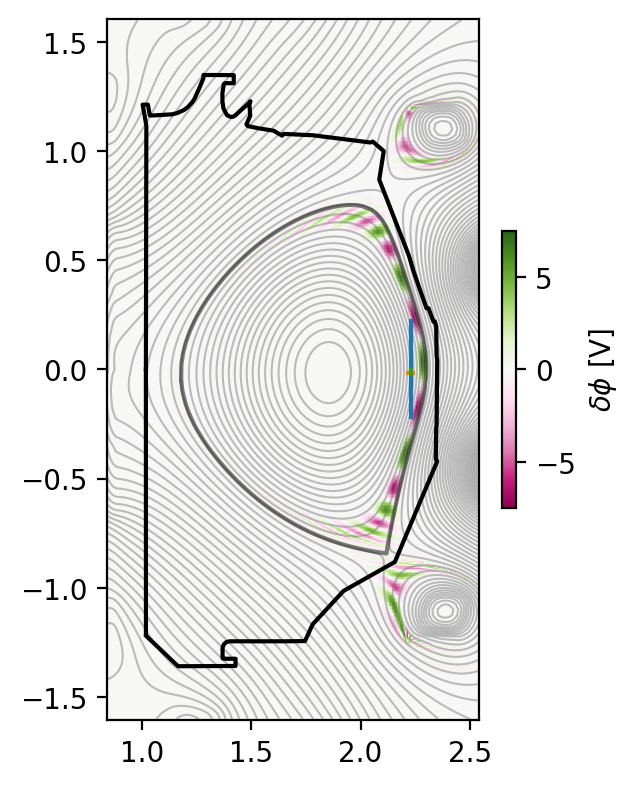

In [9]:
# %% Plot the equilibrium and the Clebsch representation
fig = plt.figure(figsize=(3, 6), dpi=200)

ax = plt.subplot(111)

eq.plot_magnetic_geometry(ax, alpha=0.5)

rgrid = np.linspace(eq.rmin, eq.rmax, 512)
zgrid = np.linspace(eq.zmin, eq.zmax, 512)
rplot, zplot = np.meshgrid(rgrid, zgrid, indexing='ij')

theta = theta_map(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)
psi = eq.interp_psi(rplot.ravel(), zplot.ravel()).reshape(rplot.shape)

alpha = clebsch.interp_alpha(psi.ravel(), theta.ravel()).reshape(psi.shape)

psi_ev, ff_ev = eq.compute_psi_and_ff(rplot.ravel(), zplot.ravel())
varphi_fluct = jnp.full_like(rplot.ravel(), 0.0)
fields_fluct = eikonal_field(0.005, rplot.ravel(), varphi_fluct, zplot.ravel(), psi_ev)
phi_fluct = fields_fluct['phi'].reshape(psi.shape)

phi_max = jnp.max(jnp.abs(phi_fluct))*1e3

pc = ax.pcolormesh(rplot, zplot, phi_fluct.reshape(psi.shape)*1e3, shading='auto', cmap='PiYG', vmin=-phi_max, vmax=phi_max)
plt.colorbar(pc, label=R'$\delta\phi$ [V]', shrink=0.3)

## From Stewart+ PPCF 2025 fig. 4, this is maybe the right poloidal wavelength on the OMP
l_poloidal = (2 * jnp.pi / 0.143) / 100.0
l_radial = 2.5 / 100.0
print((l_poloidal/4)*100, l_radial*100)
ax.plot([2.23, 2.23], [-l_poloidal/2, l_poloidal/2])
ax.plot([2.23-l_radial/2, 2.23+l_radial/2], [eq.zaxis, eq.zaxis])
ax.plot([2.23, 2.23], [eq.zaxis, eq.zaxis+0.01])

In [13]:
# %% Load the puncture data


ppuncs = particle_tools.PunctureData.empty_list_like(y0)
npuncs = particle_tools.PunctureData.empty_list_like(y0)
npuncs_poloidal = particle_tools.PunctureData.empty_list_like(y0)
ppuncs_poloidal = particle_tools.PunctureData.empty_list_like(y0)



for i in range(0,8):
    with open(f'./scratch/outputs/nt/puncs_long_pair_{i}.pkl', 'rb') as f:
        ppuncs_i, npuncs_i = pickle.load(f)
        #ppuncs_i, npuncs_i, ppuncs_pi, npuncs_pi = pickle.load(f)
    
    # Accumulate punctures
    ppuncs = jax.tree.map(lambda *xs: np.concatenate(xs), ppuncs, ppuncs_i)
    npuncs = jax.tree.map(lambda *xs: np.concatenate(xs), npuncs, npuncs_i)
    #ppuncs_poloidal = jax.tree.map(lambda *xs: np.concatenate(xs), ppuncs_poloidal, ppuncs_pi)
    #npuncs_poloidal = jax.tree.map(lambda *xs: np.concatenate(xs), npuncs_poloidal, npuncs_pi)

67
64
122
58
67
66
107
53
67
66
67
56
66
66
100
56
65
67
70
51
66
68
47
52
65
67
57
52
62
67
59
52
63
68
58
137
64
68
61
96
61
68
64
55
59
68
64
77
76
63
71
77
77
62
68
77
78
66
69
76
77
70
70
76
78
70
66
77
78
70
64
76
78
73
66
74
78
74
64
74
78
74
59
75
78
75
61
73
78
76
62
71
78
76
57


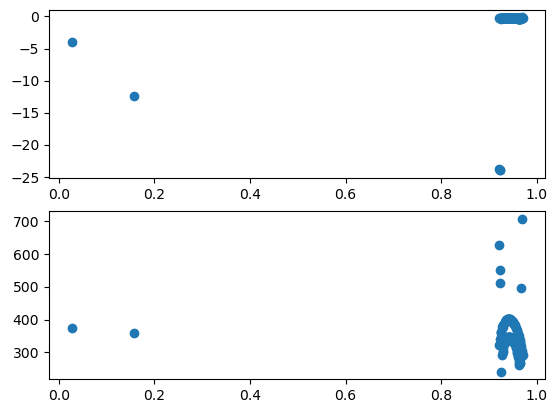

In [24]:
# %% Compute rotation numbers

nump = len(y0.r)

omega_b = np.zeros(nump)
r_avg = np.zeros(nump)
iota = np.zeros(nump)
total_phase = np.zeros(nump)

omega_eikonal = eikonal_field.omega[0]
n_eikonal = eikonal_field.n[0]

for k in range(nump):
    punc = npuncs[k]
    
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp
    print(len(r_p))
    phase = n_eikonal*varphi_p - (punc.tp*omega_eikonal) # pyright: ignore
    total_phase[k] = phase[-1] - phase[0]

    iota[k] = np.sum(wba_weights(len(phase)-1) * np.diff(phase) / n_eikonal)
    r_avg[k] = np.sum(wba_weights(len(phase)) * r_p)
    omega_b[k] = 2*np.pi / (np.sum(wba_weights(len(phase)-1) * np.diff(punc.tp)))


psi_avg = eq.interp_psi(r_avg, jnp.full_like(r_avg, eq.zaxis))
plt.figure()
plt.subplot(211)
plt.scatter(psi_avg/eq.psix, iota)
plt.subplot(212)
plt.scatter(psi_avg/eq.psix, omega_b)

In [19]:
ic['shape']

(2, 48)

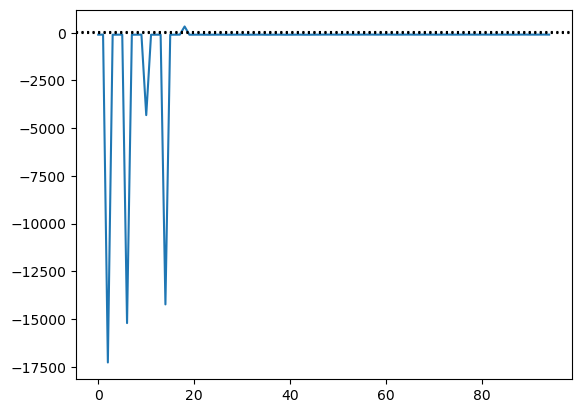

In [25]:
plt.figure()
plt.plot(total_phase)
plt.axhline(2*np.pi, ls=':', c='k')
plt.axhline(4*np.pi, ls=':', c='k')

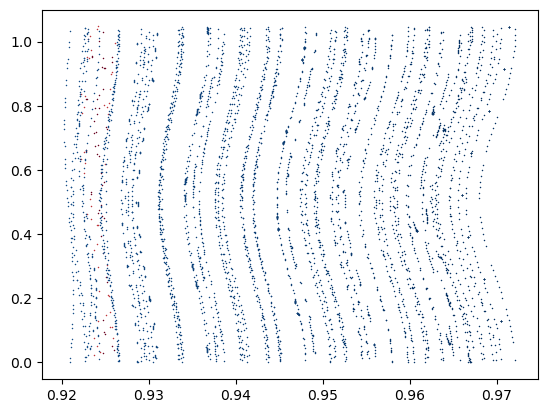

In [26]:
# %% Plot Poincare section


pp = particle_motion.ParticleParams.species('e')

plt.figure(dpi=100)

ax = plt.subplot(111)
#eq.plot_magnetic_geometry(ax, alpha=0.2)
for k in range(nump):
    punc = npuncs[k]
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp
    phase = n_eikonal*varphi_p - (punc.tp*omega_eikonal) # pyright: ignore
    psi_p = eq.interp_psi(r_p, z_p)

    color = mpl.cm.RdBu((psi_avg[k] - np.min(psi_avg))/(np.max(psi_avg) - np.min(psi_avg)))

    plt.scatter(psi_p[:48] / eq.psix, np.mod(phase[:48], 2*np.pi)/n_eikonal, s=9.0*(72/100.0)**2, lw=0.0, marker='.', color=color)

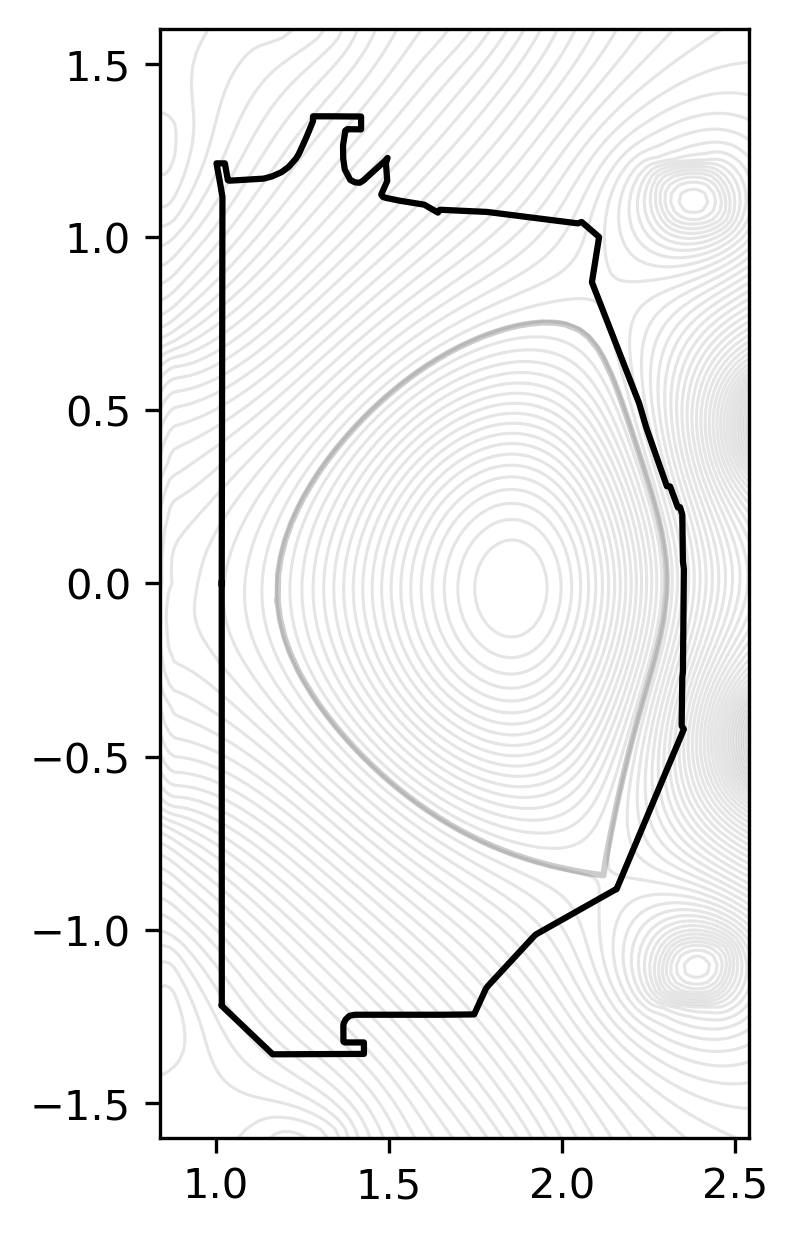

In [21]:
# %% Plot poloidal section

%matplotlib inline

plt.figure(dpi=300)

ax = plt.subplot(111)
eq.plot_magnetic_geometry(ax, alpha=0.2)

for k in range(nump):
    punc = ppuncs_poloidal[k]
    r_p, varphi_p, z_p, upar_p, mu_p = punc.yp

    color = mpl.cm.PiYG((total_phase[k] > 2*np.pi) * 1.0 * (total_phase[k] < 4*np.pi))

    plt.scatter(r_p, z_p, s=(72/300.0)**2, lw=0.0, marker='.', color=color, alpha=0.25)